In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("fraud_detection.csv")

In [3]:
df.columns

Index(['transaction_amount', 'transaction_risk_score', 'is_fraud'], dtype='object')

In [4]:
df.head()

,transaction_amount,transaction_risk_score,is_fraud
0,1.879910,-1.485035,0
1,0.377083,-2.238585,0
2,1.354312,-2.664638,0
3,-0.509843,-1.502950,0
4,0.863561,-1.906364,0


In [5]:
df["is_fraud"].unique()

array([0, 1])

In [6]:
df["is_fraud"].value_counts()

is_fraud
0    9846
1     154
Name: count, dtype: int64

In [7]:
# Imbalanced Dataset

In [8]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

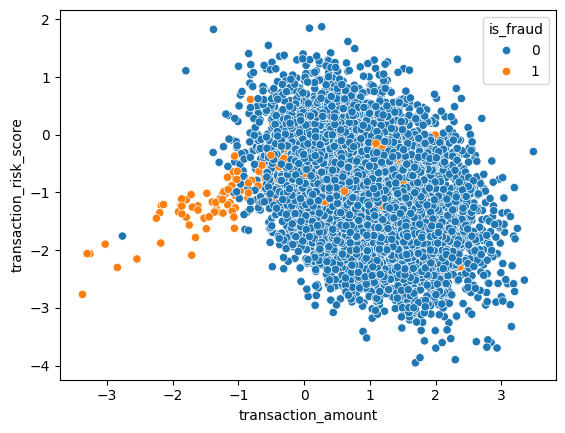

In [9]:
sns.scatterplot(x=X["transaction_amount"], y=X["transaction_risk_score"], hue=y)
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [12]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [14]:
penalty = ["l1", "l2", "elasticnet"]
c_values = [100, 10, 1.0, 0.1, 0.01]
solver = ["newton-cg", "lbfgs", "liblinear", "sag", "saga", "newton-cholesky"]
class_weight = [{0: w, 1: y} for w in [1, 10, 50, 100] for y in [1, 10, 50, 100]]

In [15]:
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [16]:
params = dict(penalty=penalty, C=c_values, solver=solver, class_weight=class_weight)

In [17]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [18]:
cv = StratifiedKFold()

In [19]:
grid = GridSearchCV(estimator=model, param_grid=params, scoring="accuracy", cv=cv)

In [20]:
import warnings
warnings.filterwarnings("ignore")

In [21]:
grid.fit(X_train, y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [22]:
y_pred = grid.predict(X_test)

In [23]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2500,))

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [25]:
print("score:", accuracy_score(y_pred, y_test))
print(classification_report(y_pred, y_test))
print("confusion matrix:\n", confusion_matrix(y_pred, y_test))


score: 0.99
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2481
           1       0.42      0.84      0.56        19

    accuracy                           0.99      2500
   macro avg       0.71      0.92      0.78      2500
weighted avg       0.99      0.99      0.99      2500

confusion matrix:
 [[2459   22]
 [   3   16]]


In [26]:
grid.best_params_

{'C': 0.01, 'class_weight': {0: 10, 1: 50}, 'penalty': 'l2', 'solver': 'saga'}

ROC & AUC

In [29]:
model_prob = grid.predict_proba(X_test)

In [30]:
model_prob

array([[0.99586363, 0.00413637],
       [0.85291376, 0.14708624],
       [0.95231591, 0.04768409],
       ...,
       [0.98898913, 0.01101087],
       [0.9845418 , 0.0154582 ],
       [0.9975868 , 0.0024132 ]], shape=(2500, 2))

In [31]:
model_prob = model_prob[:,1]

In [32]:
model_prob

array([0.00413637, 0.14708624, 0.04768409, ..., 0.01101087, 0.0154582 ,
       0.0024132 ], shape=(2500,))

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score

In [34]:
model_auc = roc_auc_score(y_test, model_prob)

In [35]:
model_auc

0.7392898371029116

In [37]:
# model false positive rate
# model true positive rate

model_fpr, model_tpr, thresholds = roc_curve(y_test, model_prob)

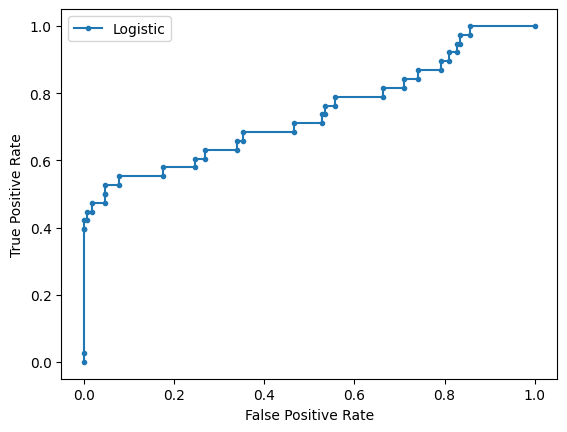

In [38]:
plt.plot(model_fpr, model_tpr, marker=".", label="Logistic")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

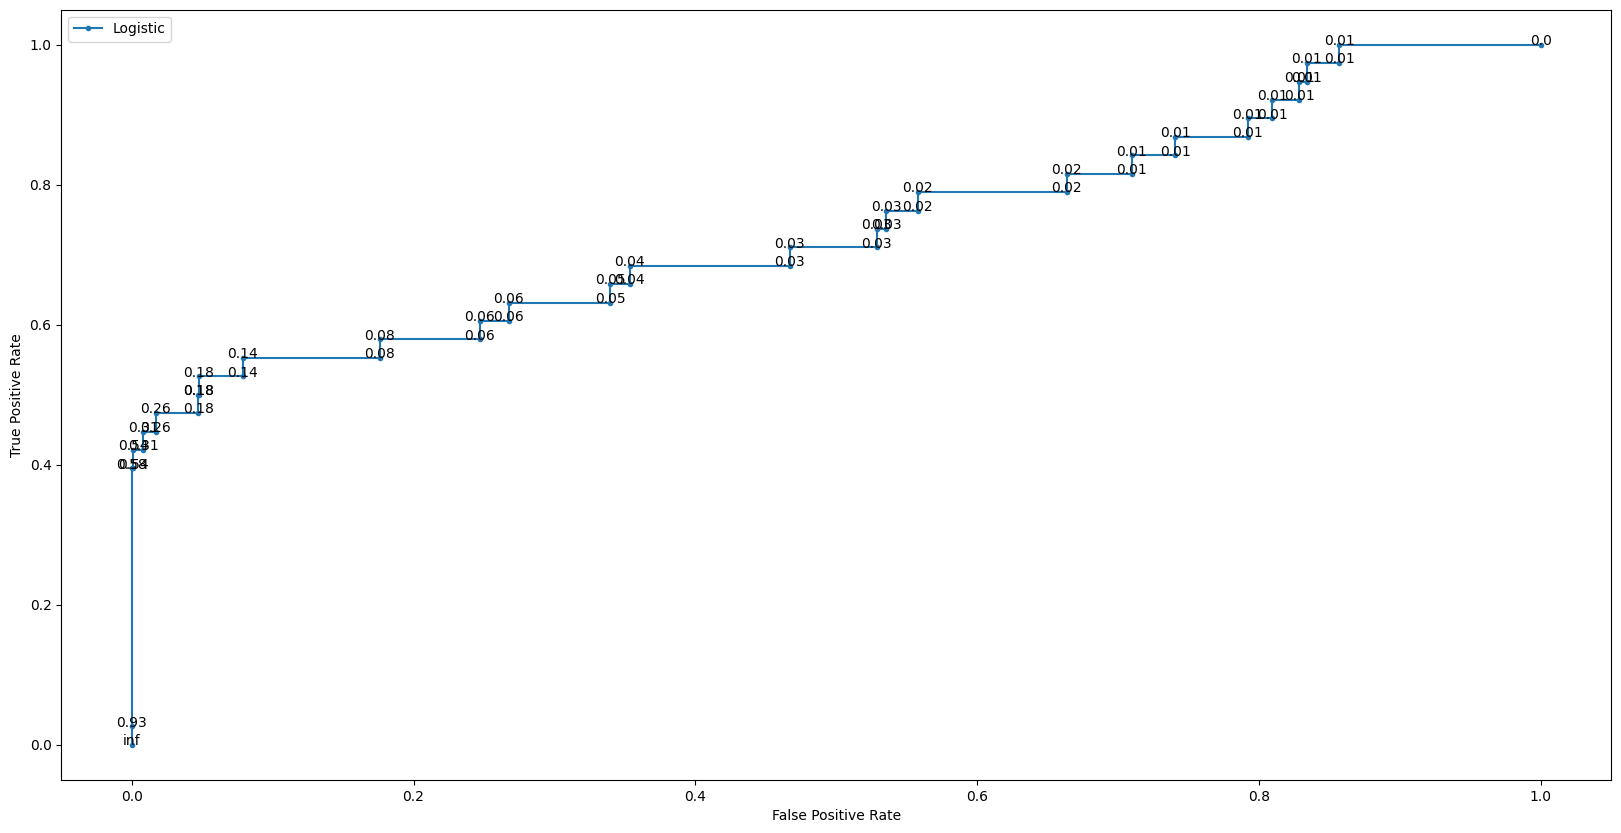

In [39]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(model_fpr, model_tpr, marker=".", label="Logistic")

for fpr, tpr, thresh in zip(model_fpr, model_tpr, thresholds):
    ax.annotate(f"{np.round(thresh, 2)}", (fpr, tpr), ha="center")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.show()

In [46]:
custom_threshold = 0.5

y_pred_custom = (model_prob >= custom_threshold).astype(int)

print(confusion_matrix(y_pred_custom, y_test))
print(classification_report(y_pred_custom, y_test))

[[2459   22]
 [   3   16]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2481
           1       0.42      0.84      0.56        19

    accuracy                           0.99      2500
   macro avg       0.71      0.92      0.78      2500
weighted avg       0.99      0.99      0.99      2500



In [43]:
y_pred_custom

array([0, 0, 0, ..., 0, 0, 0], shape=(2500,))